# Data Preprocessing  —  3-Class Setup
Melanoma · Nevus · Basal Cell Carcinoma

**Training datasets:** HIBA (paired) + Derm7pt (paired)  
**Cross-evaluation datasets:** Fitzpatrick17k · PAD-UFES-20 · ISIC2019

## Phase 0 — Environment Setup

In [203]:
!pip install -q scikit-learn matplotlib seaborn pandas tqdm Pillow scikit-image



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [204]:
import os, re, glob, random, math, json, warnings, shutil
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
print('Imports ready.')


Imports ready.


## Phase 1 — Configuration & Label Taxonomy

In [205]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIG
# ════════════════════════════════════════════════════════════════════════════
# Update DRIVE_ROOT and WORK_ROOT to match your environment.
DRIVE_ROOT = Path('C:\\Users\\asose\\OneDrive\\Desktop\\SengeResearch\\datasets')
WORK_ROOT  = Path('process\\process\\outputs')

CFG = dict(
    hiba_root     = DRIVE_ROOT / 'HIBASkinLesionsDataset-main',
    derm7pt_root  = DRIVE_ROOT / 'Derm7pt',

    # Cross-evaluation datasets (unpaired)
    fitz_root     = DRIVE_ROOT / 'fitzpatrick17k',
    padufes20_root= DRIVE_ROOT / 'PAD-UFES-20',
    isic2019_dir  = DRIVE_ROOT / 'ISIC2019',

    # Outputs
    csv_dir  = WORK_ROOT / 'csvs',
    eda_dir  = WORK_ROOT / 'eda',

    num_classes    = 3,   # melanoma / nevus / basal cell carcinoma
    num_skin_types = 6,
)

# 3-class label space
LABEL_NAMES = {
    0: 'melanoma',
    1: 'nevus',
    2: 'basal cell carcinoma',
}

FST_NAMES = {i: f'FST {i+1}' for i in range(6)}
_PAL_CLS  = ['#1950A0', '#0096B4', '#DC641E']   # one colour per class
_PAL_FST  = ['#FFEDE0', '#F4C18C', '#D49060', '#A0522D', '#5C3317', '#2B1500']

for k in ['csv_dir', 'eda_dir']:
    CFG[k].mkdir(parents=True, exist_ok=True)

print('Config ready. Checking dataset roots:')
for k in ['hiba_root','derm7pt_root','fitz_root','padufes20_root','isic2019_dir']:
    status = 'OK' if CFG[k].exists() else 'MISSING — update path'
    print(f'  [{status}]  {k}')


Config ready. Checking dataset roots:
  [OK]  hiba_root
  [OK]  derm7pt_root
  [OK]  fitz_root
  [OK]  padufes20_root
  [OK]  isic2019_dir


In [206]:
# ════════════════════════════════════════════════════════════════════════════
# LABEL TAXONOMY & SHARED HELPERS
# ════════════════════════════════════════════════════════════════════════════

VALID_LABELS = {0, 1, 2}

def _clean(s: str) -> str:
    s = str(s).lower().strip()
    s = re.sub(r'[-_]+', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s

# ── HIBA (diagnosis column) ───────────────────────────────────────────────
HIBA_MAP = {
    'melanoma':            0,
    'nevus':               1,
    'basal cell carcinoma':2,
}

# ── Derm7pt (meta.csv 'diagnosis' column) ────────────────────────────────
DERM7PT_MAP = {
    'melanoma':                     0,
    'melanoma (in situ)':           0,
    'melanoma (less than 0.76 mm)': 0,
    'melanoma (0.76 to 1.5 mm)':    0,
    'melanoma (more than 1.5 mm)':  0,
    'melanoma metastasis':          0,
    'dermal nevus':                 1,
    'clark nevus':                  1,
    'reed or spitz nevus':          1,
    'blue nevus':                   1,
    'recurrent nevus':              1,
    'combined nevus':               1,
    'congenital nevus':             1,
    'basal cell carcinoma':         2,
}

# ── Fitzpatrick17k (cross-eval) ───────────────────────────────────────────
FITZ_MAP_3CLS = {
    'melanoma': 0, 'malignant melanoma': 0, 'superficial spreading melanoma ssm': 0,
    'lentigo maligna': 0, 'lentigo maligna melanoma': 0,
    'acral lentiginous melanoma': 0, 'nodular melanoma': 0,
    'nevocytic nevus': 1, 'epidermal nevus': 1, 'congenital nevus': 1,
    'halo nevus': 1, 'becker nevus': 1,
    'nevus sebaceous of jadassohn': 1, 'naevus comedonicus': 1,
    'basal cell carcinoma': 2, 'basal cell carcinoma morpheiform': 2,
    'solid cystic basal cell carcinoma': 2,
}

# ── PAD-UFES-20 (cross-eval) ──────────────────────────────────────────────
PADUFES_MAP_3CLS = {
    'mel': 0,   # melanoma
    'nev': 1,   # nevus
    'bcc': 2,   # basal cell carcinoma
    # ack / scc / sek excluded from 3-class setup
}

# ── ISIC2019 (cross-eval, one-hot columns) ────────────────────────────────
ISIC2019_COL_MAP_3CLS = {
    'MEL': 0,
    'NV':  1,
    'BCC': 2,
}


def harmonize_label(raw: str, mapping: dict) -> 'int | None':
    s = _clean(raw)
    if s in mapping:
        v = mapping[s]
        return v if v in VALID_LABELS else None
    for k, v in mapping.items():
        if k in s or s in k:
            return v if v in VALID_LABELS else None
    if 'nevus' in s or 'nevi' in s:
        return 1
    return None

def parse_fst(raw) -> int:
    try:
        v = int(float(str(raw).strip()))
        return v - 1 if 1 <= v <= 6 else -1
    except (ValueError, TypeError):
        return -1

_ROMAN = {'i':1,'ii':2,'iii':3,'iv':4,'v':5,'vi':6}
def parse_fst_roman(raw) -> int:
    s = str(raw).lower().strip()
    if s in _ROMAN:
        return _ROMAN[s] - 1
    return parse_fst(raw)

def _verify_labels(df, name):
    if df.empty: return df
    before = len(df)
    df = df[df['label'].between(0, CFG['num_classes']-1)].copy()
    if before - len(df):
        print(f'  [WARN] {name}: dropped {before-len(df)} out-of-range rows')
    vc = df['label'].value_counts().sort_index()
    print(f'  {name}: {len(df)} rows | ' +
          '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k, v in vc.items()))
    return df

def _build_image_map(root_dir: Path, exts=['.jpg','.jpeg','.png']):
    m = {}
    for ext in exts:
        for p in root_dir.rglob(f'*{ext}'):
            m[p.stem] = p
            m[p.name] = p
    return m

def _safe_split_3way(df, val_size=0.1, test_size=0.2, seed=SEED):
    if df.empty:
        return df, df.iloc[:0], df.iloc[:0]
    cts  = df['label'].value_counts()
    rare = cts[cts < 2].index
    df_rare = df[df['label'].isin(rare)]
    df_rest = df[~df['label'].isin(rare)]
    if df_rest.empty:
        return df, df.iloc[:0], df.iloc[:0]
    
    # Handle case where test_size=0.0 (no test split, all goes to train/val)
    if test_size == 0.0:
        df_tv = df_rest.copy()
        df_test = pd.DataFrame()
    else:
        try:
            df_tv, df_test = train_test_split(df_rest, test_size=test_size,
                                              random_state=seed, stratify=df_rest['label'])
        except ValueError:
            df_tv, df_test = train_test_split(df_rest, test_size=test_size, random_state=seed)
    
    # Calculate relative validation size
    # When test_size=0.0, val_size is used directly as is
    # When test_size>0, val_size is relative to data remaining after test split
    if test_size == 0.0:
        rel_val = val_size
    else:
        rel_val = val_size / (1.0 - test_size)
    
    try:
        df_train, df_val = train_test_split(df_tv, test_size=rel_val,
                                            random_state=seed, stratify=df_tv['label'])
    except ValueError:
        df_train, df_val = train_test_split(df_tv, test_size=rel_val, random_state=seed)
    df_train = pd.concat([df_train, df_rare], ignore_index=True)
    return df_train, df_val, df_test

print('Label taxonomy & helpers ready — 3 classes: melanoma / nevus / basal cell carcinoma.')


Label taxonomy & helpers ready — 3 classes: melanoma / nevus / basal cell carcinoma.


In [207]:
# ════════════════════════════════════════════════════════════════════════════
# ITA-BASED FST ESTIMATOR  (for Derm7pt clinical images)
# ════════════════════════════════════════════════════════════════════════════

_ITA_BRACKETS = [
    ( 55.0,  float('inf'), 0),
    ( 28.0,  55.0,         1),
    ( 10.0,  28.0,         2),
    (-30.0,  10.0,         3),
    (-55.0, -30.0,         4),
    (float('-inf'), -55.0, 5),
]

def _ita_to_fst(ita: float) -> int:
    for lo, hi, fst in _ITA_BRACKETS:
        if lo < ita <= hi:
            return fst
    return _ITA_BRACKETS[-1][2]

def _estimate_fst_single(path: str, min_skin_frac: float = 0.05, thumb_size: int = 96) -> int:
    try:
        from skimage import color as _skc
        img = Image.open(path).convert('RGB').resize((thumb_size, thumb_size), Image.BILINEAR)
        rgb = np.asarray(img, dtype=np.float32) / 255.0
        lab = _skc.rgb2lab(rgb)
        L, a, b = lab[...,0], lab[...,1], lab[...,2]
        mask = (L > 20) & (L < 90) & (a > 2) & (b > 5)
        if mask.mean() < min_skin_frac:
            return -1
        mL = float(L[mask].mean()); mb = float(b[mask].mean())
        if abs(mb) < 1e-6: return -1
        return _ita_to_fst(float(np.degrees(np.arctan((mL - 50.0) / mb))))
    except Exception:
        return -1

def estimate_fst_for_df(df: pd.DataFrame, path_col: str,
                        n_jobs: int = 4, cache_csv: Path = None) -> pd.DataFrame:
    """Estimate FST via ITA for every row. Saves/loads a cache CSV."""
    if cache_csv is not None and Path(cache_csv).exists():
        cached = pd.read_csv(cache_csv)
        if 'skin_type' in cached.columns and len(cached) == len(df):
            df = df.copy()
            df['skin_type'] = cached['skin_type'].values
            n = int((df['skin_type'] >= 0).sum())
            print(f'  [FST cache] loaded {n}/{len(df)} from {Path(cache_csv).name}')
            return df
    print(f'  Estimating FST via ITA for {len(df)} images (n_jobs={n_jobs}) …')
    paths = df[path_col].tolist()
    with ThreadPoolExecutor(max_workers=n_jobs) as ex:
        fst_vals = list(tqdm(ex.map(_estimate_fst_single, paths),
                             total=len(paths), desc='  ITA-FST', leave=True))
    df = df.copy()
    df['skin_type'] = fst_vals
    n = sum(v >= 0 for v in fst_vals)
    print(f'  FST estimated: {n}/{len(df)} ({100*n/max(len(df),1):.1f}%)')
    for fi in range(6):
        cnt = sum(v == fi for v in fst_vals)
        if cnt: print(f'    FST {fi+1}: {cnt:>5}')
    if cache_csv is not None:
        df.to_csv(cache_csv, index=False)
        print(f'  Saved FST cache → {Path(cache_csv).name}')
    return df

print('ITA-FST estimator ready.')


ITA-FST estimator ready.


## Phase 2 — Dataset Parsers
### 2-A  Training Datasets (Paired)

In [208]:
# ════════════════════════════════════════════════════════════════════════════
# HIBA PARSER — 3-class (melanoma / nevus / BCC)
# ════════════════════════════════════════════════════════════════════════════

def parse_hiba_3cls(root: Path):
    candidates = (list(root.rglob('metadata.csv')) +
                  list(root.rglob('hiba_metadata.csv')) +
                  list(root.rglob('hospital-italiano-de-buenos-aires-skin-lesions-images-2019-2022.csv')))
    if not candidates:
        print(f'[WARN] HIBA: no metadata CSV under {root}'); return pd.DataFrame()

    meta = pd.read_csv(candidates[0])
    print(f'[HIBA] {len(meta)} rows loaded')

    fst_col = next((c for c in ['fitzpatrick_skin_type','fitzpatrick','fitzpatrick_scale']
                    if c in meta.columns), None)
    print(f'[HIBA] FST column: {fst_col}')
    image_map = _build_image_map(root)
    print(f'[HIBA] image map: {len(image_map)} entries')

    # Accumulate per lesion_id
    lesion_data = {}
    for _, r in meta.iterrows():
        diag  = str(r.get('diagnosis', ''))
        label = harmonize_label(diag, HIBA_MAP)
        if label is None:
            continue   # exclude non-3-class rows

        lid   = str(r['lesion_id'])
        itype = _clean(str(r.get('image_type', '')))
        isic  = str(r.get('isic_id', ''))
        fst   = parse_fst_roman(r[fst_col]) if fst_col else -1

        img_stem = None
        p = image_map.get(isic) or image_map.get(Path(isic).stem if '.' in isic else isic)
        if p:
            img_stem = Path(p).stem

        if lid not in lesion_data:
            lesion_data[lid] = {'label': label, 'fst': fst, 'clinical': [], 'derm': []}
        else:
            if fst >= 0 and lesion_data[lid]['fst'] < 0:
                lesion_data[lid]['fst'] = fst

        if img_stem:
            if 'derm' in itype:
                lesion_data[lid]['derm'].append(img_stem)
            else:
                lesion_data[lid]['clinical'].append(img_stem)

    # Build paired + unpaired pools
    paired_rows, unpaired_clin, unpaired_derm = [], [], []
    for lid, d in lesion_data.items():
        base = {'label': d['label'], 'skin_type': d['fst'], 'dataset': 'hiba'}
        if d['clinical'] and d['derm']:
            paired_rows.append({**base,
                'lesion_id': f'hiba_{lid}',
                'clinical':   d['clinical'][0],
                'derm':       d['derm'][0]})
            for p in d['clinical'][1:]:
                unpaired_clin.append({**base, 'image_id': p})
            for p in d['derm'][1:]:
                unpaired_derm.append({**base, 'image_id': p})
        else:
            for p in d['clinical']:
                unpaired_clin.append({**base, 'image_id': p})
            for p in d['derm']:
                unpaired_derm.append({**base, 'image_id': p})

    df_paired = pd.DataFrame(paired_rows)
    df_uclin  = pd.DataFrame(unpaired_clin)
    df_uderm  = pd.DataFrame(unpaired_derm)

    if not df_paired.empty:
        vc = df_paired['label'].value_counts().sort_index()
        print('[HIBA paired] classes: ' +
              '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    print(f'[HIBA] paired={len(df_paired)}  unpaired_clin={len(df_uclin)}  unpaired_derm={len(df_uderm)}')
    return df_paired, df_uclin, df_uderm

print('HIBA 3-class parser ready.')


HIBA 3-class parser ready.


In [209]:
# ════════════════════════════════════════════════════════════════════════════
# DERM7PT PARSER — 3-class TRAINING dataset (all rows are paired)
# FST estimated via ITA on clinical images
# ════════════════════════════════════════════════════════════════════════════

def parse_derm7pt_train(root: Path) -> pd.DataFrame:
    """Parse Derm7pt as a paired training source (3 classes only).

    Every row in meta.csv has both a clinical ('clinic') and dermoscopy
    ('derm') image path already — the dataset is fully paired by design.
    FST is unknown in the metadata but estimated below via ITA on the
    clinical images.

    Output columns:
        label | skin_type | dataset | lesion_id | clinical | derm
    """
    meta_csv = next(iter(root.rglob('meta.csv')), None)
    if meta_csv is None:
        print(f'[WARN] Derm7pt: meta.csv not found under {root}')
        return pd.DataFrame()

    meta = pd.read_csv(meta_csv)
    print(f'[Derm7pt] {len(meta)} rows loaded')

    image_map = _build_image_map(root)
    print(f'[Derm7pt] image map: {len(image_map)} entries')

    rows = []
    skipped = 0
    for _, r in meta.iterrows():
        label = harmonize_label(str(r.get('diagnosis', '')), DERM7PT_MAP)
        if label is None:
            skipped += 1
            continue

        clinic_raw = str(r.get('clinic', ''))
        derm_raw   = str(r.get('derm',   ''))
        # Store just the filename stem (no path, no extension)
        clin_stem = Path(clinic_raw).stem if clinic_raw not in ('', 'nan') else None
        derm_stem = Path(derm_raw).stem   if derm_raw   not in ('', 'nan') else None

        if clin_stem is None or derm_stem is None:
            skipped += 1
            continue

        # We will fill skin_type after ITA estimation
        rows.append({
            'label':       label,
            'skin_type':   -1,   # filled below
            'dataset':     'derm7pt',
            'lesion_id':   f'derm7pt_{r["case_num"]}',
            'clinical':    clin_stem,
            'derm':        derm_stem,
            '_clin_path':  str(image_map.get(clin_stem, image_map.get(Path(clinic_raw).name, ''))),
        })

    df = pd.DataFrame(rows)
    print(f'[Derm7pt] {len(df)} rows kept | {skipped} skipped (outside 3 classes)')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('[Derm7pt] classes: ' +
              '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))

    # ── Estimate FST via ITA on clinical images ───────────────────────────
    _cache = CFG['csv_dir'] / 'derm7pt_train_fst_cache.csv'
    df = estimate_fst_for_df(df, path_col='_clin_path', n_jobs=4, cache_csv=_cache)
    df = df.drop(columns=['_clin_path'], errors='ignore')
    return df

print('Derm7pt 3-class training parser ready.')


Derm7pt 3-class training parser ready.


### 2-B  Cross-Evaluation Dataset Parsers

In [210]:
# ════════════════════════════════════════════════════════════════════════════
# FITZPATRICK17K PARSER — 3-class cross-eval (clinical images)
# ════════════════════════════════════════════════════════════════════════════

def parse_fitzpatrick17k_3cls(root: Path) -> pd.DataFrame:
    csvs = list(root.glob('fitzpatrick17k.csv'))
    if not csvs:
        print('[WARN] Fitzpatrick17k CSV missing'); return pd.DataFrame()
    meta    = pd.read_csv(csvs[0])
    img_dir = root / 'data' / 'finalfitz17k' if (root/'data/finalfitz17k').exists() else root
    image_map = _build_image_map(img_dir)
    print(f'[Fitz] {len(meta)} rows | image map: {len(image_map)} entries')

    rows, skipped = [], 0
    for _, r in meta.iterrows():
        raw   = str(r.get('label', r.get('nine_partition_label', '')))
        label = harmonize_label(raw, FITZ_MAP_3CLS)
        if label is None:
            skipped += 1; continue
        fst_raw = r.get('fitzpatrick_scale', r.get('fitzpatrick', -1))
        fst = parse_fst(fst_raw) if str(fst_raw).strip() not in ('-1','-1.0','nan','') else -1
        p = None
        for col in ['md5hash','image_id','file_name']:
            if col in r.index and pd.notna(r[col]):
                cid = str(r[col])
                p = image_map.get(cid) or image_map.get(Path(cid).stem if '.' in cid else cid)
                if p: break
        if p is None: continue
        rows.append({'clinical': Path(p).stem, 'label': label,
                     'skin_type': fst, 'dataset': 'fitzpatrick17k'})

    df = pd.DataFrame(rows)
    print(f'[Fitz] {len(df)} rows kept | {skipped} skipped (outside 3 classes)')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    return df

print('Fitzpatrick17k 3-class parser ready.')


Fitzpatrick17k 3-class parser ready.


In [211]:
# ════════════════════════════════════════════════════════════════════════════
# PAD-UFES-20 PARSER — 3-class cross-eval (clinical images)
# ════════════════════════════════════════════════════════════════════════════

def parse_padufes20_3cls(root: Path) -> pd.DataFrame:
    candidates = list(root.rglob('metadata.csv')) + list(root.rglob('pad_ufes_20_metadata.csv'))
    if not candidates:
        print(f'[WARN] PAD-UFES-20: no metadata CSV under {root}'); return pd.DataFrame()

    meta = pd.read_csv(candidates[0])
    print(f'[PAD-UFES-20] {len(meta)} rows | columns: {list(meta.columns)}')

    fst_col = next((c for c in ['fitspatrick','fitzpatrick','fitzpatrick_skin_type']
                    if c in meta.columns), None)
    print(f'[PAD-UFES-20] FST column: {fst_col}')

    rows, skipped = [], 0
    for _, r in meta.iterrows():
        diag  = str(r.get('diagnostic', '')).strip().lower()
        label = PADUFES_MAP_3CLS.get(diag, None)
        if label is None:
            skipped += 1; continue
        img_id    = Path(str(r.get('img_id', ''))).stem
        lesion_id = f"padufes_{r['lesion_id']}" if 'lesion_id' in meta.columns and pd.notna(r.get('lesion_id')) else None
        fst       = parse_fst(r[fst_col]) if fst_col and pd.notna(r.get(fst_col)) else -1
        rows.append({'label': label, 'skin_type': fst, 'dataset': 'padufes20',
                     'lesion_id': lesion_id, 'clinical': img_id})

    df = pd.DataFrame(rows)
    print(f'[PAD-UFES-20] {len(df)} rows kept | {skipped} skipped (outside 3 classes, incl ACK/SCC/SEK)')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
        n_fst = int((df['skin_type'] >= 0).sum())
        print(f'  FST known: {n_fst}/{len(df)} ({100*n_fst/max(len(df),1):.1f}%)')
    return df

print('PAD-UFES-20 3-class parser ready.')


PAD-UFES-20 3-class parser ready.


In [212]:
# ════════════════════════════════════════════════════════════════════════════
# ISIC2019 PARSER — 3-class cross-eval (dermoscopic images)
# ════════════════════════════════════════════════════════════════════════════

def parse_isic2019_3cls(train_csv: Path, test_csv: Path) -> pd.DataFrame:
    dfs = []
    for csv_path, tag in [(train_csv, 'train'), (test_csv, 'test')]:
        if not Path(csv_path).exists():
            print(f'[WARN] ISIC2019: {csv_path} not found — skipping {tag}'); continue
        raw = pd.read_csv(csv_path)
        print(f'[ISIC2019] {tag}: {len(raw)} rows')
        rows, skipped = [], 0
        for _, r in raw.iterrows():
            label = None
            for col, lbl in ISIC2019_COL_MAP_3CLS.items():
                if col in r and r[col] == 1.0:
                    label = lbl; break
            if label is None:
                skipped += 1; continue
            rows.append({'label': label, 'skin_type': -1,
                         'dataset': 'isic2019', 'derm': str(r.get('image', ''))})
        part = pd.DataFrame(rows)
        print(f'  kept {len(part)} | skipped (excluded classes): {skipped}')
        dfs.append(part)

    if not dfs: return pd.DataFrame()
    df = pd.concat(dfs, ignore_index=True)
    print(f'[ISIC2019] total: {len(df)} rows')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    return df

print('ISIC2019 3-class parser ready.')


ISIC2019 3-class parser ready.


## Phase 3 — Build & Save All CSVs

In [213]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD ALL CSVs  (Paired → 70/10/20 train/val/test; HIBA residuals → additional test set)
# ════════════════════════════════════════════════════════════════════════════
print('='*65)
print('Step 1: Parsing training datasets …')
print()

# ── HIBA ─────────────────────────────────────────────────────────────────
hiba_paired, hiba_uclin, hiba_uderm = parse_hiba_3cls(CFG['hiba_root'])

# ── Derm7pt ───────────────────────────────────────────────────────────────
derm7pt_paired = parse_derm7pt_train(CFG['derm7pt_root'])

# ── Combine ALL paired data ───────────────────────────────────────────────
print()
print('Step 2: Combining paired pools …')
df_paired_all = pd.concat([hiba_paired, derm7pt_paired, hiba_uclin, hiba_uderm], ignore_index=True)
df_paired = pd.concat([hiba_paired, derm7pt_paired], ignore_index=True)
df_paired = _verify_labels(df_paired, 'All paired (HIBA + Derm7pt)')

# HIBA unpaired (clinical and derm residuals) → TEST SET ONLY
# NOTE: Derm7pt is fully paired; no unpaired residuals from it.
df_uclin_all = hiba_uclin.copy()
df_uderm_all = hiba_uderm.copy()
if not df_uclin_all.empty:
    df_uclin_all = df_uclin_all.rename(columns={'image_id': 'clinical'})
if not df_uderm_all.empty:
    df_uderm_all = df_uderm_all.rename(columns={'image_id': 'derm'})
df_uclin_all = _verify_labels(df_uclin_all, 'Unpaired clinical (HIBA residuals)')
df_uderm_all = _verify_labels(df_uderm_all, 'Unpaired derm (HIBA residuals)')

# ── Split paired data: 70/10/20 train/val/test ───────────────────────────
print()
print('Step 3: Splitting paired data into 70/10/20 train/val/test …')
paired_train, paired_val, paired_test = _safe_split_3way(df_paired, val_size=0.1, test_size=0.2)
paired_train_update, paired_val, paired_test = _safe_split_3way(df_paired_all, val_size=0.1, test_size=0.2)

# ── Test set: all HIBA residual clin/derm (no further splitting) ─────────
clin_test = df_uclin_all.copy() if not df_uclin_all.empty else pd.DataFrame()
derm_test = df_uderm_all.copy() if not df_uderm_all.empty else pd.DataFrame()

print(f'  Paired Train  : {len(paired_train)}')
print(f'  Paired Val    : {len(paired_val)}')
print(f'  Paired Test   : {len(paired_test)}')
print(f'  Clin Test     : {len(clin_test)}')
print(f'  Derm Test     : {len(derm_test)}')

total_train = len(paired_train)
total_val   = len(paired_val)
total_test  = len(paired_test) + len(clin_test) + len(derm_test)
print(f'  Total train/val/test: {total_train} / {total_val} / {total_test}')
print(f'  ✓ Paired data split 70/10/20; HIBA residuals form an additional test set')

# ── Parse cross-eval datasets ─────────────────────────────────────────────
print()
print('Step 4: Parsing cross-evaluation datasets …')
fitz_eval   = parse_fitzpatrick17k_3cls(CFG['fitz_root'])
padufes_eval= parse_padufes20_3cls(CFG['padufes20_root'])
isic_eval   = parse_isic2019_3cls(
    CFG['isic2019_dir']/'ISIC_2019_Training_GroundTruth.csv',
    CFG['isic2019_dir']/'ISIC_2019_Test_GroundTruth.csv',
)

fitz_eval    = _verify_labels(fitz_eval,    'Fitzpatrick17k eval')
padufes_eval = _verify_labels(padufes_eval, 'PAD-UFES-20 eval')
isic_eval    = _verify_labels(isic_eval,    'ISIC2019 eval')

# ── Save all CSVs ─────────────────────────────────────────────────────────
print()
print('Step 5: Saving CSVs …')
csv_dir = CFG['csv_dir']
save_map = {
    'paired_train.csv'  : paired_train,
    'paired_train_update.csv'  : paired_train_update,
    'paired_val.csv'    : paired_val,
    'paired_test.csv'   : paired_test,
    'clin_test.csv'     : clin_test,
    'derm_test.csv'     : derm_test,
    'eval_fitzpatrick17k.csv': fitz_eval,
    'eval_padufes20.csv'     : padufes_eval,
    'eval_isic2019.csv'      : isic_eval,
}
for fname, df in save_map.items():
    if not df.empty:
        df.to_csv(csv_dir / fname, index=False)
        print(f'  Saved {fname:<30} ({len(df):>6} rows)')

Step 1: Parsing training datasets …

[HIBA] 1616 rows loaded
[HIBA] FST column: fitzpatrick_skin_type
[HIBA] image map: 3232 entries
[HIBA paired] classes: melanoma=43  nevus=44  basal cell carcinoma=99
[HIBA] paired=186  unpaired_clin=38  unpaired_derm=785
[Derm7pt] 1011 rows loaded
[Derm7pt] image map: 4026 entries
[Derm7pt] 869 rows kept | 142 skipped (outside 3 classes)
[Derm7pt] classes: melanoma=252  nevus=575  basal cell carcinoma=42
  [FST cache] loaded 811/869 from derm7pt_train_fst_cache.csv

Step 2: Combining paired pools …
  All paired (HIBA + Derm7pt): 1055 rows | melanoma=295  nevus=619  basal cell carcinoma=141
  Unpaired clinical (HIBA residuals): 38 rows | melanoma=16  nevus=9  basal cell carcinoma=13
  Unpaired derm (HIBA residuals): 785 rows | melanoma=151  nevus=505  basal cell carcinoma=129

Step 3: Splitting paired data into 70/10/20 train/val/test …
  Paired Train  : 738
  Paired Val    : 188
  Paired Test   : 376
  Clin Test     : 38
  Derm Test     : 785
  Tota

## Phase 4 — EDA Visualisations
### 4-A  Training Set: Class & FST Distributions

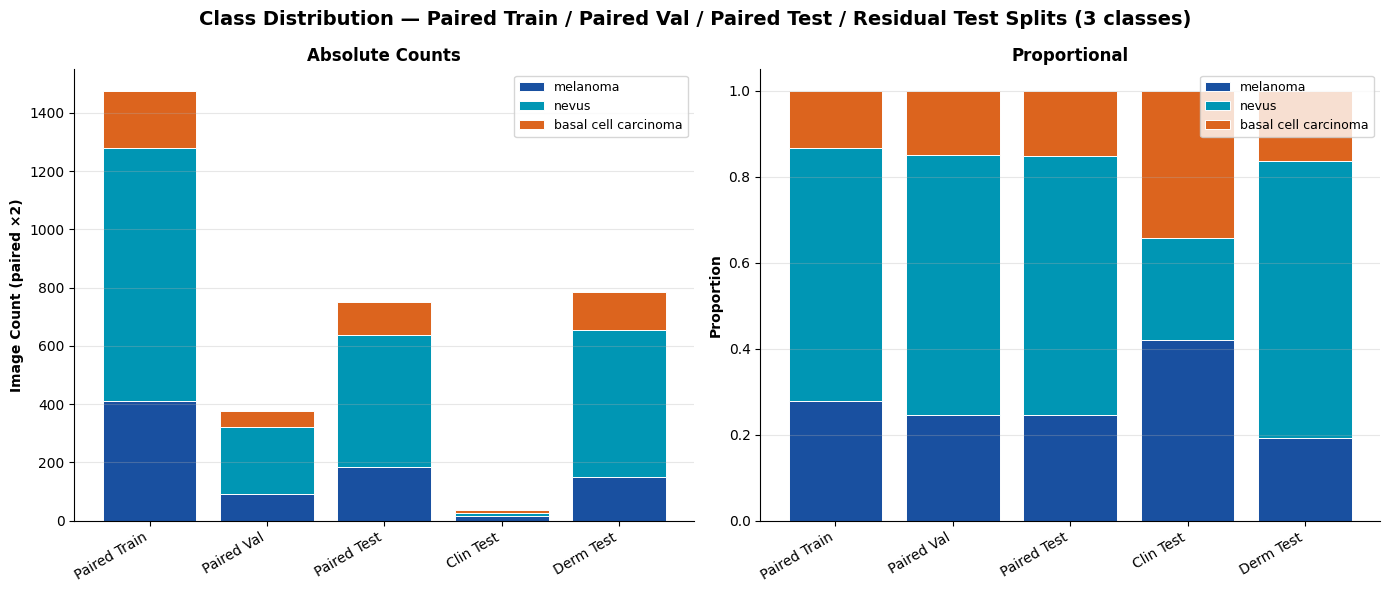

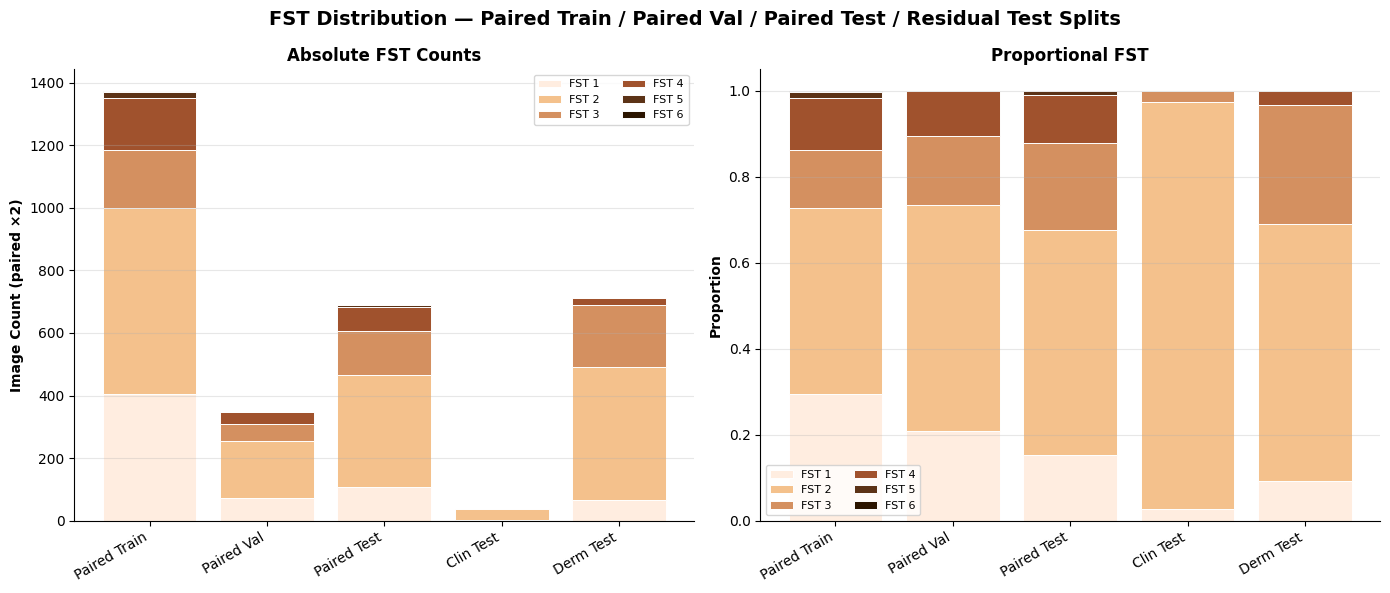

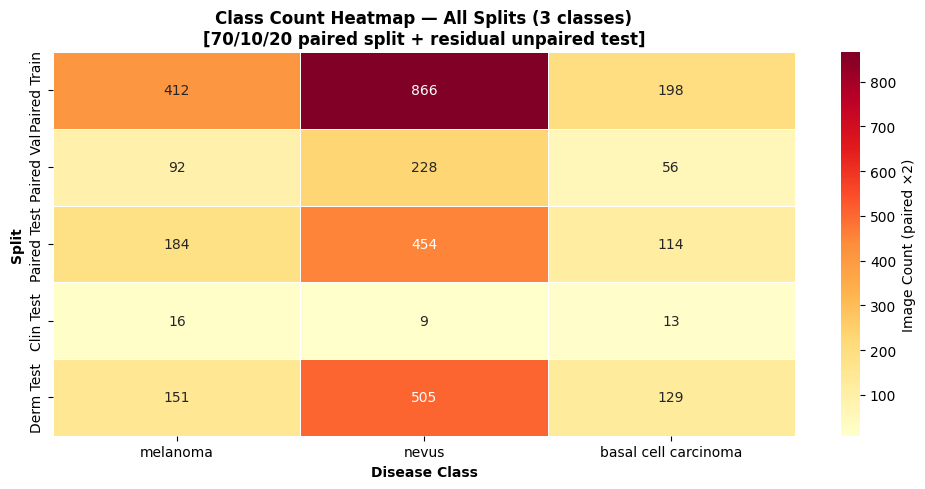

Training EDA saved.


In [214]:
# ════════════════════════════════════════════════════════════════════════════
# EDA — PAIRED-ONLY TRAINING SETUP: Class & FST Distributions
# ════════════════════════════════════════════════════════════════════════════
csv_dir = CFG['csv_dir']
_LN  = LABEL_NAMES
_LBL = [_LN[i] for i in range(3)]

def _load(fname):
    p = csv_dir / fname
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

# Load all available splits
_tr_splits = {
    'Paired Train':       _load('paired_train.csv'),
    'Paired Val':         _load('paired_val.csv'),
    'Paired Test':        _load('paired_test.csv'),
    'Clin Test':          _load('clin_test.csv'),
    'Derm Test':          _load('derm_test.csv'),
}
_tr_splits = {k: v for k, v in _tr_splits.items() if not v.empty}

# ── FIG 1: Class distribution across all train/val/test splits ──────────────
if _tr_splits:
    _snames = list(_tr_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Class Distribution — Paired Train / Paired Val / Paired Test / Residual Test Splits (3 classes)',
                 fontsize=14, fontweight='bold')
    x = np.arange(len(_snames))
    bot_abs = np.zeros(len(_snames)); bot_prop = np.zeros(len(_snames))
    # Each paired row contains two images (clinical + derm), so image count = rows * 2
    _PAIRED = {'Paired Train', 'Paired Val', 'Paired Test'}
    totals = np.array([len(_tr_splits[s]) * (2 if s in _PAIRED else 1) for s in _snames], dtype=float)
    for ci, lbl in enumerate(_LBL):
        vals = np.array([_tr_splits[s]['label'].value_counts().get(ci,0) * (2 if s in _PAIRED else 1) for s in _snames])
        axes[0].bar(x, vals, bottom=bot_abs,  color=_PAL_CLS[ci], label=lbl,
                    edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(totals,1), bottom=bot_prop, color=_PAL_CLS[ci],
                    label=lbl, edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(totals,1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute Counts', 'Image Count (paired ×2)'),
        (axes[1], 'Proportional',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_snames, rotation=30, ha='right', fontsize=10)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['eda_dir']/'eda_class_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── FIG 2: FST distribution across splits ──────────────────────────────────
_fst_splits = {s: d for s, d in _tr_splits.items()
               if 'skin_type' in d.columns and (d['skin_type'] >= 0).any()}
if _fst_splits:
    _fs = list(_fst_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('FST Distribution — Paired Train / Paired Val / Paired Test / Residual Test Splits', fontsize=14, fontweight='bold')
    x = np.arange(len(_fs)); bot_abs = np.zeros(len(_fs)); bot_prop = np.zeros(len(_fs))
    for fi in range(6):
        _fst_paired = {'Paired Train', 'Paired Val', 'Paired Test'}
        vals  = np.array([(d['skin_type']==fi).sum() * (2 if s in _fst_paired else 1)
                          for s, d in _fst_splits.items()])
        known = np.array([(d['skin_type']>=0).sum()  * (2 if s in _fst_paired else 1)
                          for s, d in _fst_splits.items()], dtype=float)
        axes[0].bar(x, vals, bottom=bot_abs, color=_PAL_FST[fi], label=f'FST {fi+1}',
                    edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(known,1), bottom=bot_prop, color=_PAL_FST[fi],
                    label=f'FST {fi+1}', edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(known,1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute FST Counts', 'Image Count (paired ×2)'),
        (axes[1], 'Proportional FST',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_fs, rotation=30, ha='right', fontsize=10)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['eda_dir']/'eda_fst_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── FIG 3: Class imbalance heatmap ─────────────────────────────────────────
_hm_keys = ['Paired Train', 'Paired Val', 'Paired Test', 'Clin Test', 'Derm Test']
_hm_data = {}
for k in _hm_keys:
    d = _tr_splits.get(k)
    if d is not None and not d.empty:
        _is_paired_split = k in {'Paired Train', 'Paired Val', 'Paired Test'}
        _hm_data[k] = [d['label'].value_counts().get(ci,0) * (2 if _is_paired_split else 1) for ci in range(3)]
if _hm_data:
    _hm_df = pd.DataFrame(_hm_data, index=[_LN[i] for i in range(3)]).T
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(_hm_df, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
                linecolor='white', ax=ax, cbar_kws={'label': 'Image Count (paired ×2)'})
    ax.set_title('Class Count Heatmap — All Splits (3 classes)\n[70/10/20 paired split + residual unpaired test]',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Disease Class', fontweight='bold')
    ax.set_ylabel('Split', fontweight='bold')
    plt.tight_layout()
    plt.savefig(CFG['eda_dir']/'eda_imbalance_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Training EDA saved.')

### 4-B  Cross-Evaluation Datasets: Class & FST Distributions

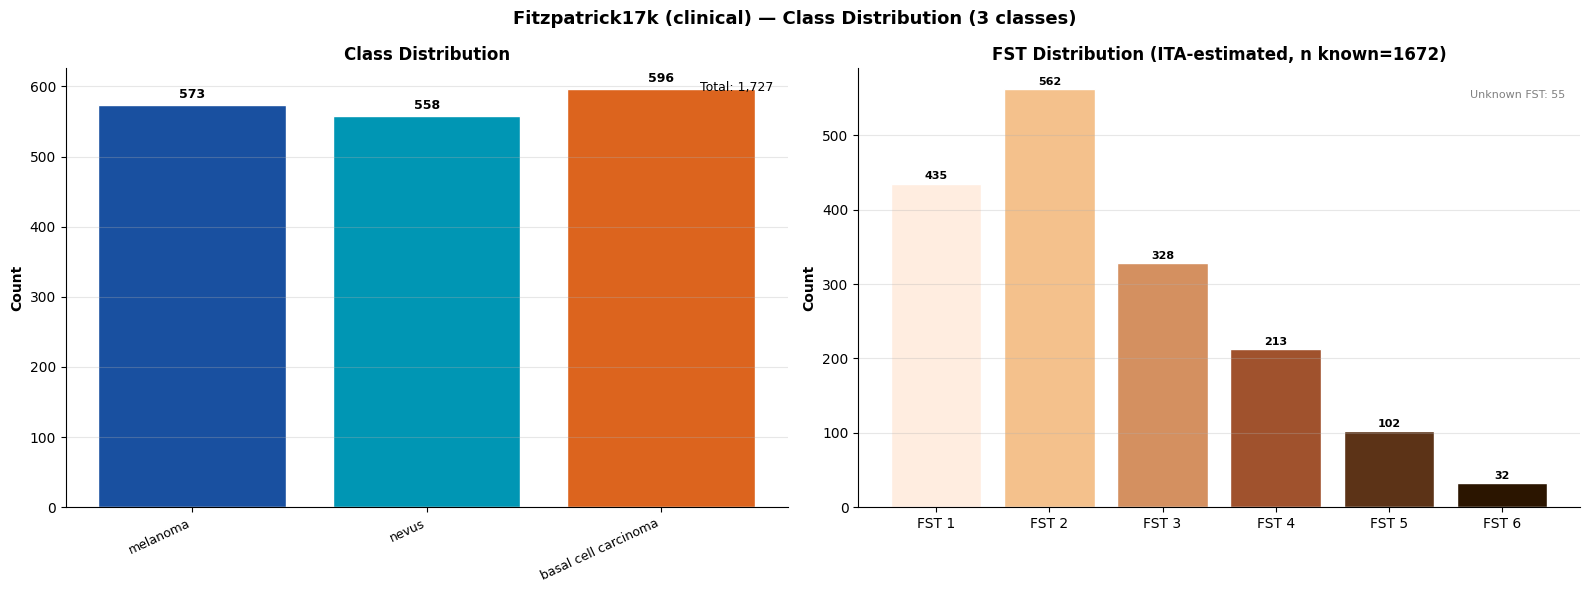

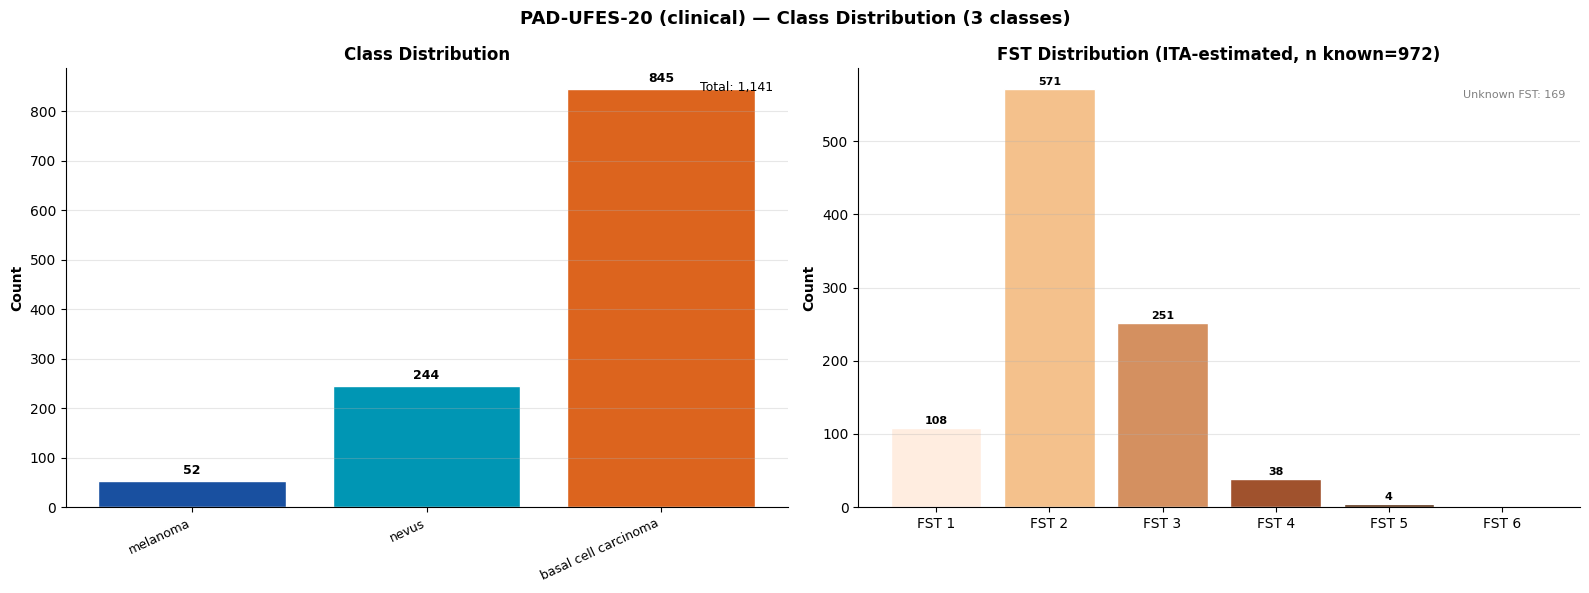

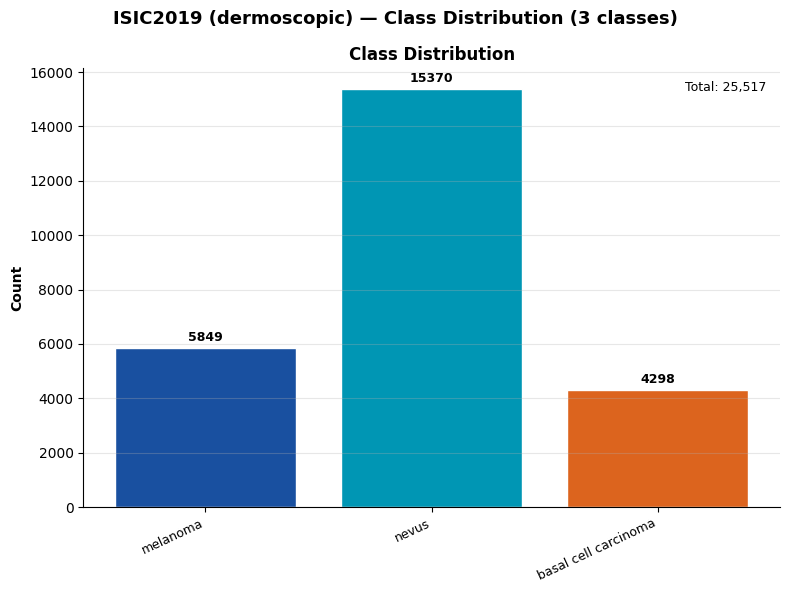

Cross-evaluation EDA saved.


In [215]:
# ════════════════════════════════════════════════════════════════════════════
# EDA — CROSS-EVALUATION DATASET DISTRIBUTIONS
# ════════════════════════════════════════════════════════════════════════════

_eval_sets = {
    'Fitzpatrick17k (clinical)': _load('eval_fitzpatrick17k.csv'),
    'PAD-UFES-20 (clinical)':    _load('eval_padufes20.csv'),
    'ISIC2019 (dermoscopic)':    _load('eval_isic2019.csv'),
}
_eval_sets = {k: v for k, v in _eval_sets.items() if not v.empty}

for ds_name, df_ev in _eval_sets.items():
    has_fst = 'skin_type' in df_ev.columns and (df_ev['skin_type'] >= 0).any()
    ncols   = 2 if has_fst else 1
    fig, axes = plt.subplots(1, ncols, figsize=(8*ncols, 6))
    if ncols == 1:
        axes = [axes]
    fig.suptitle(f'{ds_name} — Class Distribution (3 classes)',
                 fontsize=13, fontweight='bold')

    # Class distribution
    vc = df_ev['label'].value_counts().sort_index()
    bar_cols = [_PAL_CLS[i] for i in vc.index]
    bars = axes[0].bar([_LN.get(i,f'C{i}') for i in vc.index],
                       vc.values, color=bar_cols, edgecolor='white', lw=1)
    for b, n in zip(bars, vc.values):
        axes[0].text(b.get_x()+b.get_width()/2, n+vc.values.max()*0.01,
                     str(n), ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[0].set_title('Class Distribution', fontweight='bold')
    axes[0].set_xticklabels([_LN.get(i,f'C{i}') for i in vc.index],
                             rotation=25, ha='right', fontsize=9)
    axes[0].set_ylabel('Count', fontweight='bold')
    axes[0].text(0.98, 0.97, f'Total: {len(df_ev):,}',
                 transform=axes[0].transAxes, ha='right', va='top', fontsize=9)
    axes[0].grid(axis='y', alpha=0.3); axes[0].spines[['top','right']].set_visible(False)

    # FST distribution (if available)
    if has_fst:
        fst_ns = [(df_ev['skin_type']==fi).sum() for fi in range(6)]
        n_unk  = int((df_ev['skin_type'] < 0).sum())
        n_kn   = int((df_ev['skin_type'] >= 0).sum())
        fst_src = 'ground-truth' if 'padufes' in ds_name.lower() else 'ITA-estimated'
        b2 = axes[1].bar([f'FST {fi+1}' for fi in range(6)], fst_ns,
                         color=_PAL_FST, edgecolor='white', lw=1)
        for bar, n in zip(b2, fst_ns):
            if n:
                axes[1].text(bar.get_x()+bar.get_width()/2, n+max(fst_ns)*0.01,
                             str(n), ha='center', fontsize=8, fontweight='bold')
        axes[1].set_title(f'FST Distribution ({fst_src}, n known={n_kn})',
                          fontweight='bold')
        axes[1].set_ylabel('Count', fontweight='bold')
        axes[1].text(0.98, 0.95, f'Unknown FST: {n_unk}',
                     transform=axes[1].transAxes, ha='right', va='top',
                     fontsize=8, color='grey')
        axes[1].grid(axis='y', alpha=0.3)
        axes[1].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    safe_name = ds_name.split(' ')[0].lower()
    plt.savefig(CFG['eda_dir']/f'eda_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Cross-evaluation EDA saved.')


### 4-C  Clinical / Dermoscopy Image Pairs per Class

Building image maps for pair visualisation …


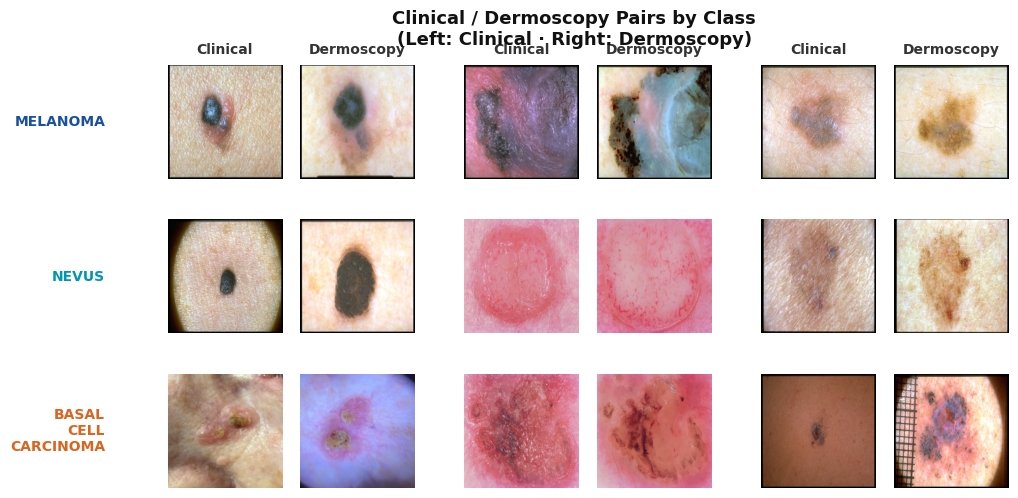

Pair visualisation saved → eda_pairs_by_class.png


In [216]:
# ════════════════════════════════════════════════════════════════════════════
# EDA — VISUALISE CLINICAL / DERM PAIRS FOR EACH CLASS
# Shows 3 example pairs per class (one row = one lesion, two columns = modalities).
# Pulls from paired_train.csv (HIBA + Derm7pt combined).
# ════════════════════════════════════════════════════════════════════════════

def _resolve_image_path(stem: str, image_maps: list) -> str | None:
    """Try to find a full path for a given image stem across multiple image maps."""
    for im in image_maps:
        p = im.get(stem)
        if p:
            return str(p)
    return None

# Build image maps for both datasets
print('Building image maps for pair visualisation …')
_hiba_img_map   = _build_image_map(CFG['hiba_root'])
_derm7pt_img_map= _build_image_map(CFG['derm7pt_root'])
_all_maps       = [_hiba_img_map, _derm7pt_img_map]

_paired_df = _load('paired_train.csv')

if _paired_df.empty:
    print('[SKIP] paired_train.csv is empty — skipping pair visualisation.')
else:
    N_PAIRS_PER_CLASS = 3
    CLASSES = list(range(CFG['num_classes']))

    # Create a compact figure with nested spacers for visual grouping
    fig = plt.figure(figsize=(11, 5.5))
    fig.suptitle('Clinical / Dermoscopy Pairs by Class\n'
                 '(Left: Clinical · Right: Dermoscopy)',
                 fontsize=13, fontweight='bold', y=0.98, color='#111111')

    # 3 rows (for classes), 8 columns (including spacers to group each pair)
    # Spacers at cols 2 and 5 create clear visual separation between the 3 pairs
    width_ratios = [1, 1, 0.2, 1, 1, 0.2, 1, 1]
    gs = gridspec.GridSpec(len(CLASSES), 8, width_ratios=width_ratios, hspace=0.35, wspace=0.06)

    for ci, cls_idx in enumerate(CLASSES):
        cls_name = LABEL_NAMES[cls_idx]
        subset   = _paired_df[_paired_df['label'] == cls_idx].copy()
        subset   = subset.sample(min(N_PAIRS_PER_CLASS, len(subset)),
                                 random_state=SEED).reset_index(drop=True)

        first_ax = None
        for col_idx in range(N_PAIRS_PER_CLASS):
            # Subplot columns in GridSpec:
            # Pair 0 -> cols 0, 1
            # Pair 1 -> cols 3, 4
            # Pair 2 -> cols 6, 7
            c_col = col_idx * 3
            d_col = col_idx * 3 + 1

            ax_c = fig.add_subplot(gs[ci, c_col])
            ax_d = fig.add_subplot(gs[ci, d_col])
            if col_idx == 0:
                first_ax = ax_c

            # Clean and compact axes styling
            for ax in (ax_c, ax_d):
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)

            if col_idx < len(subset):
                row = subset.iloc[col_idx]
                clin_path = _resolve_image_path(str(row.get('clinical', '')), _all_maps)
                derm_path = _resolve_image_path(str(row.get('derm', '')),     _all_maps)

                for ax, path, modality in [(ax_c, clin_path, 'Clinical'),
                                            (ax_d, derm_path, 'Dermoscopy')]:
                    if path and Path(path).exists():
                        try:
                            # Load and resize to a perfectly uniform square size
                            img = Image.open(path).convert('RGB')
                            img = img.resize((256, 256))
                            ax.imshow(img)
                        except Exception:
                            ax.imshow(np.ones((256, 256, 3)) * 0.9)
                            ax.text(128, 128, 'Load Error', ha='center', va='center',
                                    fontsize=9, color='#666666', fontweight='bold')
                    else:
                        ax.imshow(np.ones((256, 256, 3)) * 0.9)
                        ax.text(128, 128, 'Not Found', ha='center', va='center',
                                fontsize=9, color='#666666', fontweight='bold')
                    
                    # Add concise top titles only for the first row to keep it clean
                    if ci == 0:
                        ax.set_title(modality, fontsize=10, fontweight='bold', pad=8, color='#333333')
            else:
                # Placeholder for missing pair in case dataset has too few cases
                for ax in (ax_c, ax_d):
                    ax.imshow(np.ones((256, 256, 3)) * 0.95)
                    ax.text(128, 128, 'N/A', ha='center', va='center', fontsize=9, color='#999999')
                    if ci == 0:
                        ax.set_title('N/A', fontsize=10, fontweight='bold', pad=8, color='#999999')

        # Add horizontal class labels in the left margin of the first column
        # Replace spaces with newlines for compact layout
        if first_ax is not None:
            first_ax.set_ylabel(
                cls_name.upper().replace(' ', '\n'), 
                rotation=0, 
                labelpad=45, 
                ha='right', 
                va='center', 
                fontsize=10, 
                fontweight='bold', 
                color=_PAL_CLS[ci]
            )

    plt.savefig(CFG['eda_dir']/'eda_pairs_by_class.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Pair visualisation saved → eda_pairs_by_class.png')


### 4-D  Coverage Summary

Creating raw source distribution visualizations …
[HIBA] 1616 rows loaded
[HIBA] FST column: fitzpatrick_skin_type
[HIBA] image map: 3232 entries
[HIBA paired] classes: melanoma=43  nevus=44  basal cell carcinoma=99
[HIBA] paired=186  unpaired_clin=38  unpaired_derm=785
[Derm7pt] 1011 rows loaded
[Derm7pt] image map: 4026 entries
[Derm7pt] 869 rows kept | 142 skipped (outside 3 classes)
[Derm7pt] classes: melanoma=252  nevus=575  basal cell carcinoma=42
  [FST cache] loaded 811/869 from derm7pt_train_fst_cache.csv


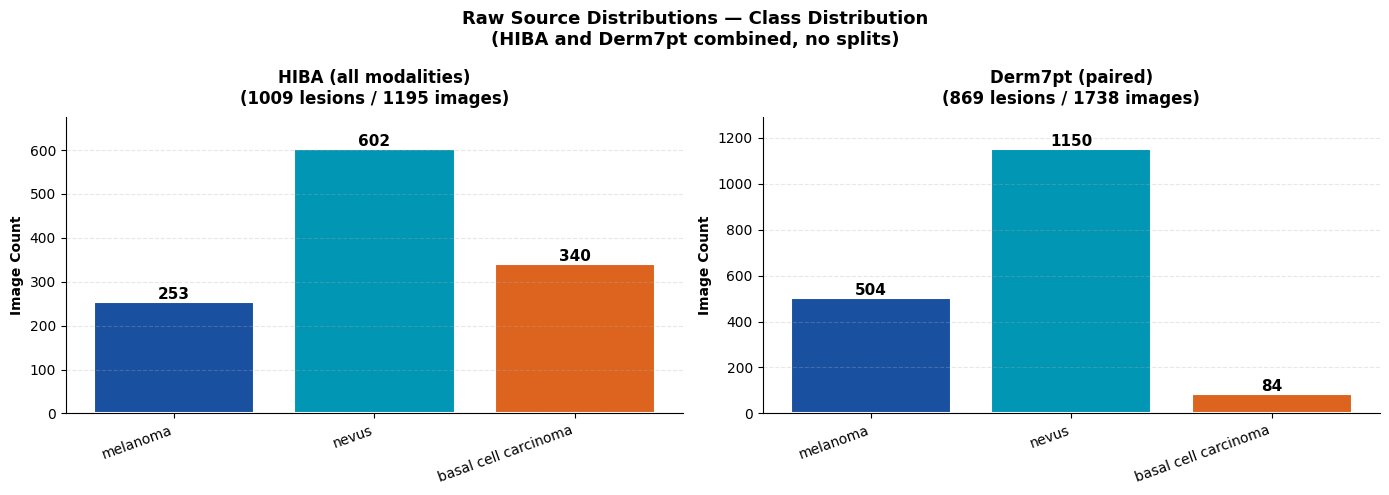

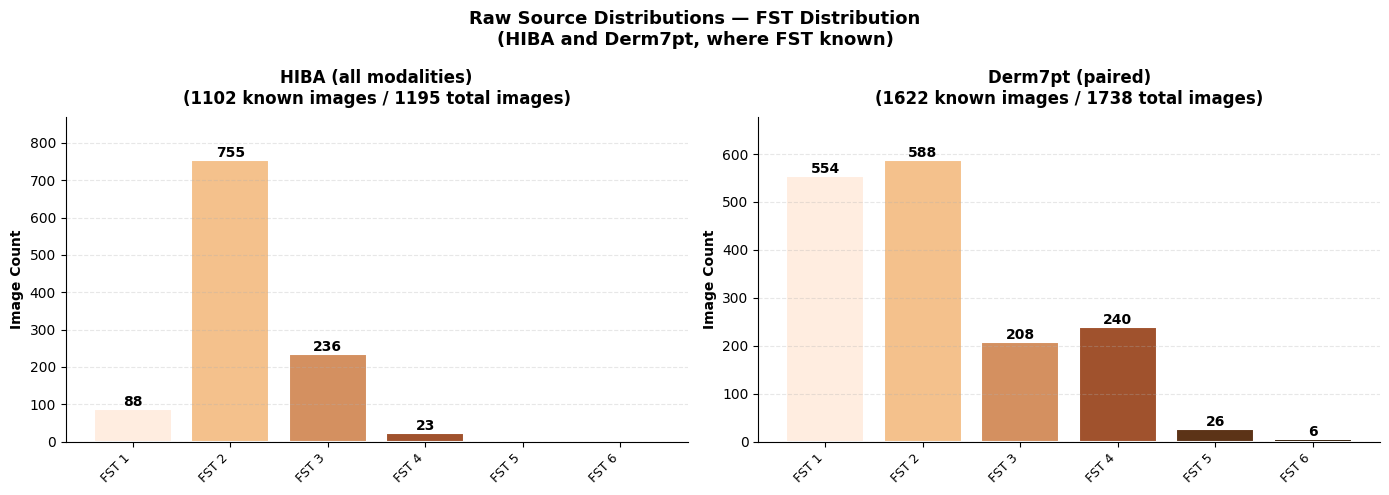

Raw source distributions saved.


In [217]:
# ════════════════════════════════════════════════════════════════════════════
# RAW SOURCE DISTRIBUTIONS — HIBA vs Derm7pt (before splitting)
# ════════════════════════════════════════════════════════════════════════════

print('Creating raw source distribution visualizations …')

# Reload raw source data (before any splitting)
hiba_paired_raw, hiba_uclin_raw, hiba_uderm_raw = parse_hiba_3cls(CFG['hiba_root'])
derm7pt_paired_raw = parse_derm7pt_train(CFG['derm7pt_root'])

# Combine all HIBA data (paired + unpaired)
hiba_all_rows = []
if not hiba_paired_raw.empty:
    hiba_paired_raw['_source'] = 'paired'
    hiba_all_rows.append(hiba_paired_raw)
if not hiba_uclin_raw.empty:
    hiba_uclin_raw['_source'] = 'unpaired_clin'
    hiba_all_rows.append(hiba_uclin_raw)
if not hiba_uderm_raw.empty:
    hiba_uderm_raw['_source'] = 'unpaired_derm'
    hiba_all_rows.append(hiba_uderm_raw)

hiba_all = pd.concat(hiba_all_rows, ignore_index=True) if hiba_all_rows else pd.DataFrame()
derm7pt_all = derm7pt_paired_raw.copy()

# ── IMAGE COUNT HELPERS ────────────────────────────────────────────────────
# HIBA: paired rows = 2 images each; unpaired_clin / unpaired_derm = 1 image each
# Derm7pt: fully paired = 2 images per row
def _img_counts_from_df(df, is_fully_paired=False):
    """Return per-row image count Series and total image count."""
    if df.empty:
        return 0, 0
    if is_fully_paired:
        mult = 2
        return df['label'].value_counts().sort_index() * mult, len(df) * mult
    # Mixed HIBA: use _source column
    img_per_row = df['_source'].map({'paired': 2, 'unpaired_clin': 1, 'unpaired_derm': 1}).fillna(1).astype(int)
    total_imgs = int(img_per_row.sum())
    # Per-class image count
    per_class = {}
    for cls in df['label'].unique():
        mask = df['label'] == cls
        per_class[cls] = int(img_per_row[mask].sum())
    import pandas as _pd
    vc_imgs = _pd.Series(per_class).sort_index()
    return vc_imgs, total_imgs

# ── CLASS DISTRIBUTION ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Raw Source Distributions — Class Distribution\n(HIBA and Derm7pt combined, no splits)',
             fontsize=13, fontweight='bold', y=0.98)

for ax, data, label, is_fully_paired in [
    (axes[0], hiba_all,     'HIBA (all modalities)', False),
    (axes[1], derm7pt_all,  'Derm7pt (paired)',      True),
]:
    if data.empty:
        ax.text(0.5, 0.5, f'{label} is empty', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='red')
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    vc_imgs, n_imgs = _img_counts_from_df(data, is_fully_paired)
    n_lesions = len(data)
    class_names = [LABEL_NAMES.get(i, f'Class {i}') for i in vc_imgs.index]
    counts = vc_imgs.values
    colors = [_PAL_CLS[i] for i in vc_imgs.index]

    bars = ax.bar(class_names, counts, color=colors, edgecolor='white', linewidth=1.5)

    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_title(f'{label}\n({n_lesions} lesions / {n_imgs} images)', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Image Count', fontweight='bold', fontsize=10)
    ax.set_xticklabels(class_names, rotation=20, ha='right', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    max_count = counts.max() if len(counts) > 0 else 100
    ax.set_ylim(0, max_count * 1.12)

plt.tight_layout()
plt.savefig(CFG['eda_dir']/'eda_raw_source_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── FST DISTRIBUTION ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Raw Source Distributions — FST Distribution\n(HIBA and Derm7pt, where FST known)',
             fontsize=13, fontweight='bold', y=0.98)

for ax, data, label, is_fully_paired in [
    (axes[0], hiba_all,     'HIBA (all modalities)', False),
    (axes[1], derm7pt_all,  'Derm7pt (paired)',      True),
]:
    if data.empty or 'skin_type' not in data.columns or not (data['skin_type'] >= 0).any():
        ax.text(0.5, 0.5, f'{label}\nNo FST data', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='gray')
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    # Compute per-FST image counts (paired rows count twice)
    if is_fully_paired:
        fst_counts = [int((data['skin_type'] == fi).sum()) * 2 for fi in range(6)]
        n_known_imgs = int((data['skin_type'] >= 0).sum()) * 2
        n_total_imgs = len(data) * 2
    else:
        img_per_row = data['_source'].map({'paired': 2, 'unpaired_clin': 1, 'unpaired_derm': 1}).fillna(1).astype(int)
        fst_counts = [int(img_per_row[data['skin_type'] == fi].sum()) for fi in range(6)]
        known_mask = data['skin_type'] >= 0
        n_known_imgs = int(img_per_row[known_mask].sum())
        n_total_imgs = int(img_per_row.sum())
    n_lesions = len(data)
    fst_labels = [f'FST {fi+1}' for fi in range(6)]

    bars = ax.bar(fst_labels, fst_counts, color=_PAL_FST, edgecolor='white', linewidth=1.5)

    for bar, count in zip(bars, fst_counts):
        if count > 0:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(count)}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(f'{label}\n({n_known_imgs} known images / {n_total_imgs} total images)',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Image Count', fontweight='bold', fontsize=10)
    ax.set_xticklabels(fst_labels, rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    max_count = max(fst_counts) if fst_counts else 100
    ax.set_ylim(0, max_count * 1.15)

plt.tight_layout()
plt.savefig(CFG['eda_dir']/'eda_raw_source_fst_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Raw source distributions saved.')


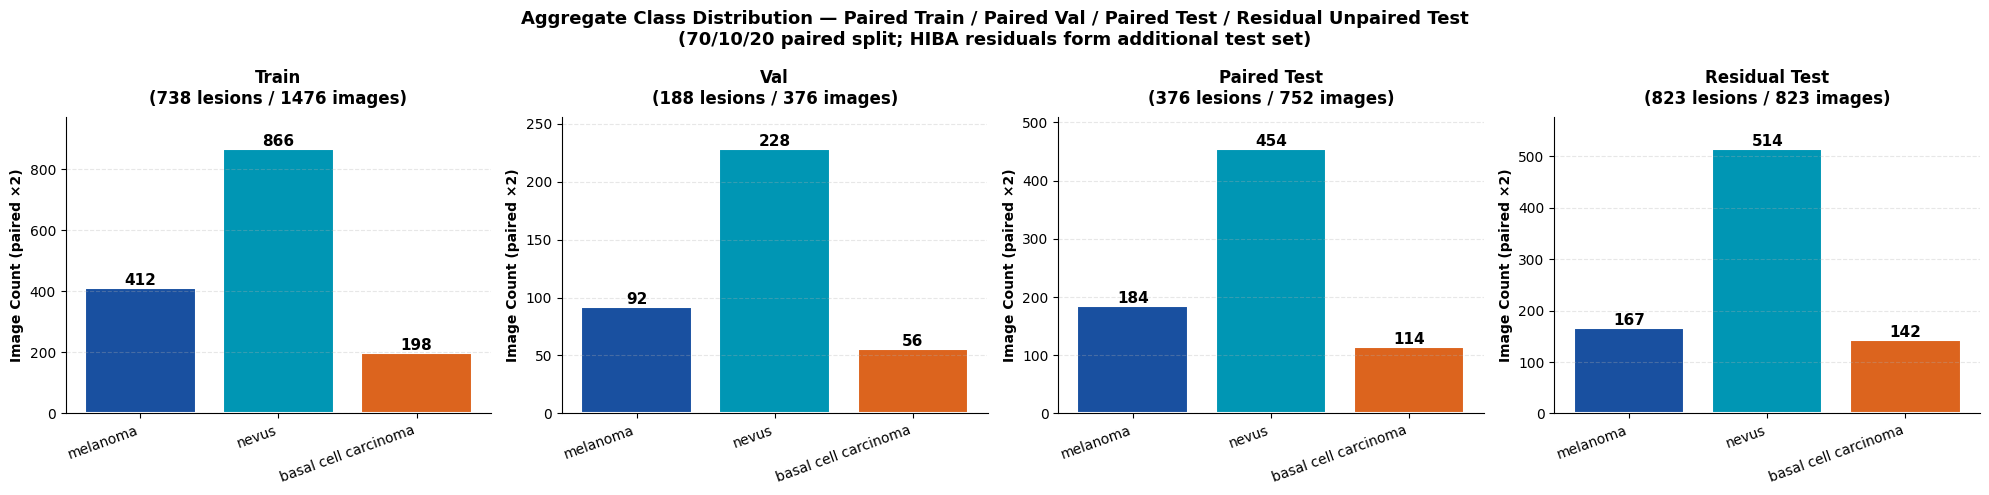

Aggregate class distribution plot saved → eda_aggregate_class_all_splits.png


In [218]:
# ════════════════════════════════════════════════════════════════════════════
# AGGREGATE CLASS DISTRIBUTION — Train/Val/Test with counts on bars
# ════════════════════════════════════════════════════════════════════════════

# Load splits directly (paired 70/10/20; residual clin/derm as extra test)
_agg_train = _load('paired_train.csv')
_agg_val   = _load('paired_val.csv')
_agg_paired_test = _load('paired_test.csv')
_agg_test_clin = _load('clin_test.csv')
_agg_test_derm = _load('derm_test.csv')
_agg_residual_test = pd.concat([_agg_test_clin, _agg_test_derm], ignore_index=True) if not _agg_test_clin.empty or not _agg_test_derm.empty else pd.DataFrame()

# Create figure with 3 subplots (one per split)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Aggregate Class Distribution — Paired Train / Paired Val / Paired Test / Residual Unpaired Test\n(70/10/20 paired split; HIBA residuals form additional test set)',
             fontsize=13, fontweight='bold', y=0.98)

# Paired splits contain two images per row (clinical + derm)
_PAIRED_NAMES = {'Train', 'Val', 'Paired Test'}
splits = [
    (_agg_train,         'Train',         axes[0]),
    (_agg_val,           'Val',           axes[1]),
    (_agg_paired_test,   'Paired Test',   axes[2]),
    (_agg_residual_test, 'Residual Test', axes[3]),
]

for df_split, split_name, ax in splits:
    if df_split.empty:
        ax.text(0.5, 0.5, f'{split_name} set is empty', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='red')
        ax.set_xticks([]); ax.set_yticks([])
        continue
    
    # Get class counts — paired rows contain 2 images each
    _img_mult = 2 if split_name in _PAIRED_NAMES else 1
    vc = df_split['label'].value_counts().sort_index()
    class_labels = [LABEL_NAMES.get(i, f'Class {i}') for i in vc.index]
    counts = vc.values * _img_mult
    colors = [_PAL_CLS[i] for i in vc.index]
    
    # Create bars
    bars = ax.bar(class_labels, counts, color=colors, edgecolor='white', linewidth=1.5)
    
    # Add count labels on top of each bar
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Styling
    ax.set_title(f'{split_name}\n({len(df_split)} lesions / {len(df_split)*_img_mult} images)', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Image Count (paired ×2)', fontweight='bold', fontsize=10)
    ax.set_xticklabels(class_labels, rotation=20, ha='right', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)
    
    # Set y-axis to allow space for labels
    max_count = counts.max() if len(counts) > 0 else 100
    ax.set_ylim(0, max_count * 1.12)

plt.tight_layout()
plt.savefig(CFG['eda_dir']/'eda_aggregate_class_all_splits.png', dpi=150, bbox_inches='tight')
plt.show()

print('Aggregate class distribution plot saved → eda_aggregate_class_all_splits.png')


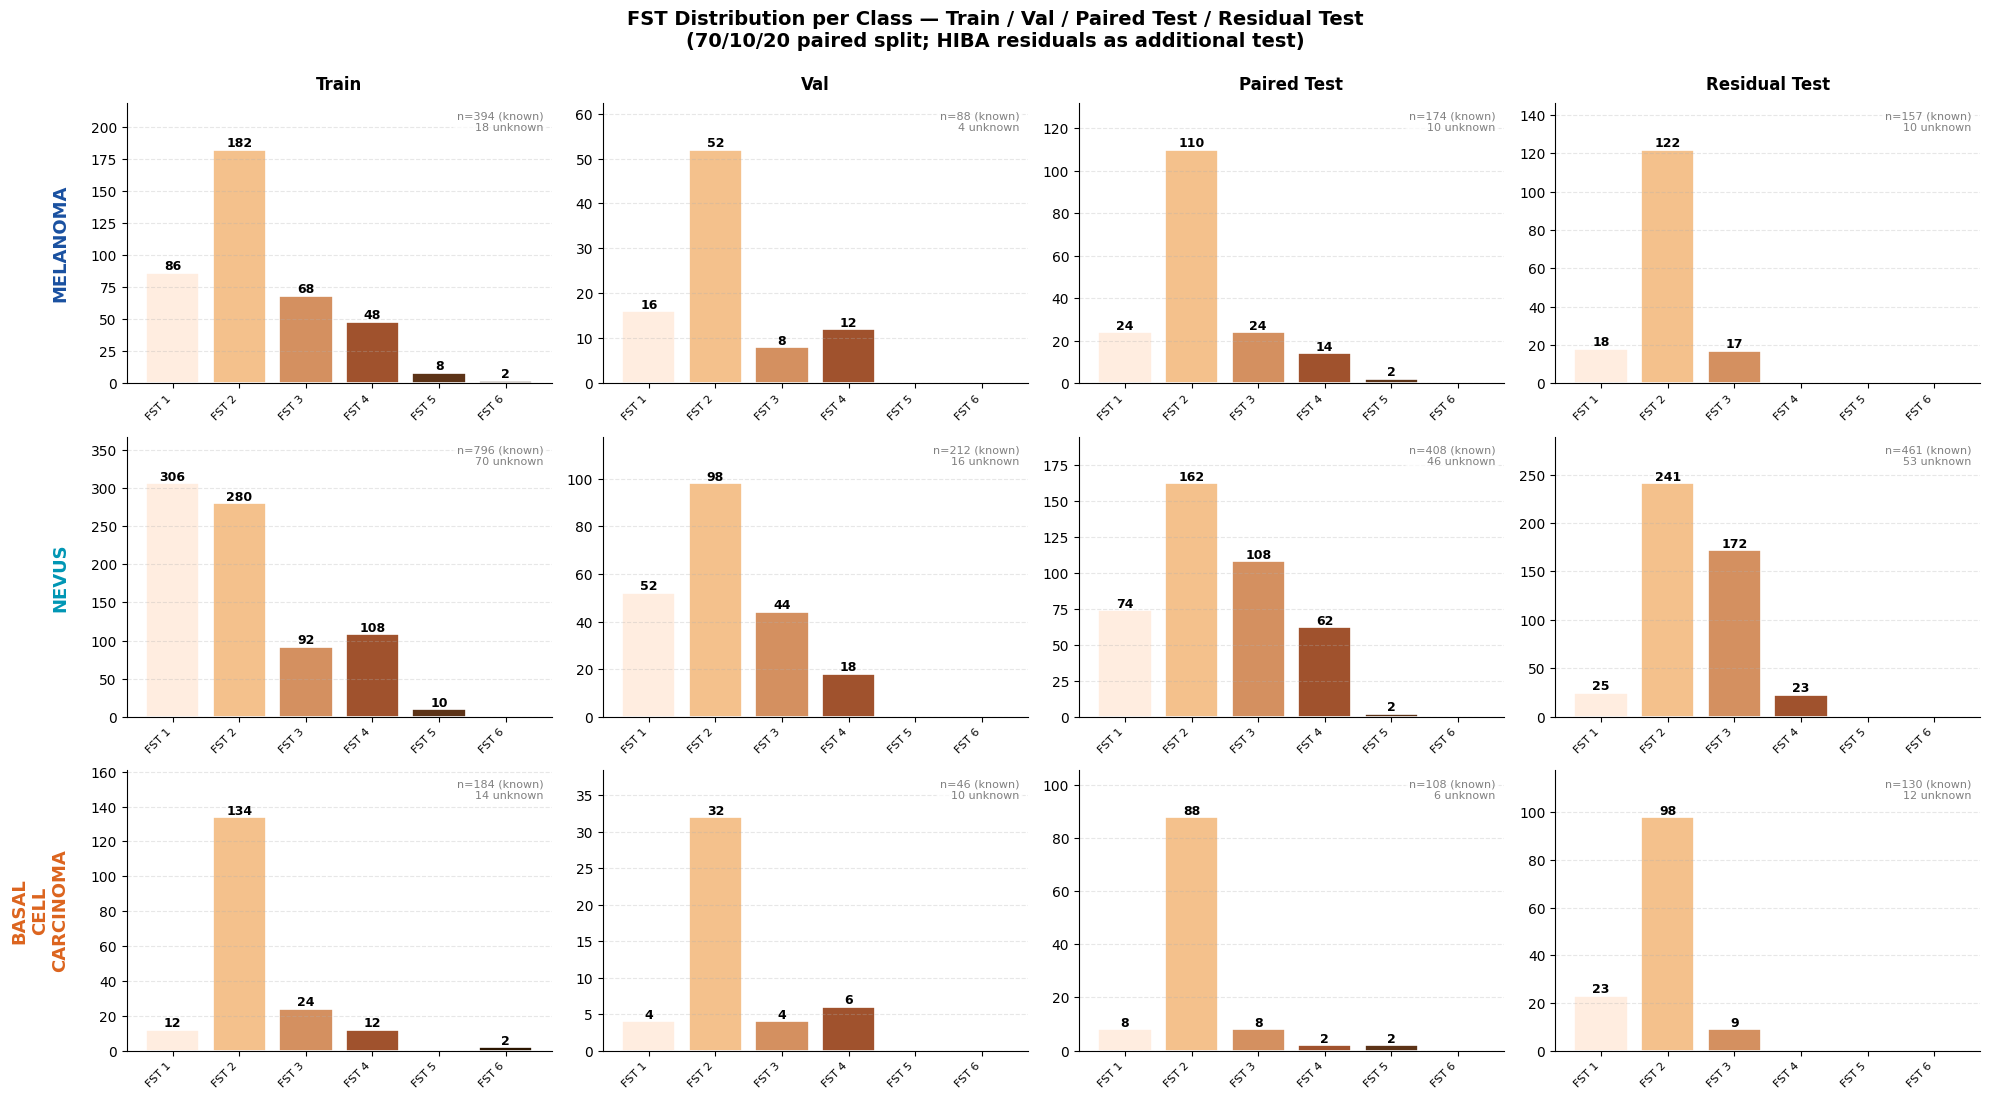

FST per-class distribution plot saved → eda_fst_per_class_train_val_test.png


In [219]:
# ════════════════════════════════════════════════════════════════════════════
# FST DISTRIBUTION PER CLASS — Across Train/Val/Test Splits (Paired-only setup)
# ════════════════════════════════════════════════════════════════════════════

# Create a figure with 3 rows (one per class) and 4 columns (one per split)
fig, axes = plt.subplots(3, 4, figsize=(20, 11))
fig.suptitle('FST Distribution per Class — Train / Val / Paired Test / Residual Test\n(70/10/20 paired split; HIBA residuals as additional test)',
             fontsize=14, fontweight='bold', y=0.995)

_PAIRED_NAMES_26 = {'Train', 'Val', 'Paired Test'}
splits_data = [
    (_agg_train,         'Train'),
    (_agg_val,           'Val'),
    (_agg_paired_test,   'Paired Test'),
    (_agg_residual_test, 'Residual Test'),
]

class_indices = [0, 1, 2]

for row_idx, cls_idx in enumerate(class_indices):
    cls_name = LABEL_NAMES[cls_idx]
    
    for col_idx, (df_split, split_name) in enumerate(splits_data):
        ax = axes[row_idx, col_idx]
        
        if df_split.empty:
            ax.text(0.5, 0.5, f'{split_name} empty', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='red')
            ax.set_xticks([]); ax.set_yticks([])
            continue
        
        # Each paired lesion has 2 images; multiply counts accordingly
        _img_mult26 = 2 if split_name in _PAIRED_NAMES_26 else 1
        # Filter for this class
        df_class = df_split[df_split['label'] == cls_idx]
        
        if df_class.empty:
            ax.text(0.5, 0.5, f'No {cls_name}', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
            continue
        
        # Get FST distribution (only samples with known FST)
        df_class_fst = df_class[df_class['skin_type'] >= 0]
        n_known = len(df_class_fst) * _img_mult26
        n_unknown = (len(df_class) - len(df_class_fst)) * _img_mult26
        
        if n_known == 0:
            ax.text(0.5, 0.5, f'No FST data\n({len(df_class)*_img_mult26} images)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
            continue
        
        # Count FST values (0-5)
        fst_counts = [int((df_class_fst['skin_type'] == fi).sum()) * _img_mult26 for fi in range(6)]
        fst_labels = [f'FST {fi+1}' for fi in range(6)]
        
        # Create bars
        bars = ax.bar(fst_labels, fst_counts, color=_PAL_FST, edgecolor='white', linewidth=1.2)
        
        # Add count labels on top of bars
        for bar, count in zip(bars, fst_counts):
            if count > 0:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(count)}',
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Title: class name on left, split info on top
        if col_idx == 0:
            ax.set_ylabel(cls_name.replace(' ', '\n').upper(), fontweight='bold', fontsize=13, 
                         color=_PAL_CLS[cls_idx], labelpad=15)
        
        if row_idx == 0:
            ax.set_title(f'{split_name}', fontsize=12, fontweight='bold', pad=10)
        
        # Styling
        ax.set_xticklabels(fst_labels, rotation=45, ha='right', fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.spines[['top', 'right']].set_visible(False)
        
        # Add info text about FST coverage
        ax.text(0.98, 0.97, f'n={n_known} (known)\n{n_unknown} unknown',
                transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))
        
        # Set y-axis limit with some headroom
        if max(fst_counts) > 0:
            ax.set_ylim(0, max(fst_counts) * 1.2)

plt.tight_layout()
plt.savefig(CFG['eda_dir']/'eda_fst_per_class_train_val_test.png', dpi=150, bbox_inches='tight')
plt.show()

print('FST per-class distribution plot saved → eda_fst_per_class_train_val_test.png')


In [220]:
# ════════════════════════════════════════════════════════════════════════════
# COVERAGE SUMMARY — Paired-only training setup
# ════════════════════════════════════════════════════════════════════════════

# is_paired=True → each row contains 2 images; counts are multiplied by 2
_all_sources = [
    ('Paired Train (HIBA + Derm7pt)',  'paired_train.csv',          'paired',   'ground-truth', True),
    ('Paired Val (HIBA + Derm7pt)',    'paired_val.csv',            'paired',   'ground-truth', True),
    ('Paired Test (HIBA + Derm7pt)',   'paired_test.csv',           'paired',   'ground-truth', True),
    ('Clin Test (HIBA residuals)',     'clin_test.csv',             'clinical', 'ground-truth', False),
    ('Derm Test (HIBA residuals)',     'derm_test.csv',             'derm',     'ground-truth', False),
    ('Fitzpatrick17k (cross-eval)',    'eval_fitzpatrick17k.csv',   'clinical', 'ground-truth', False),
    ('PAD-UFES-20 (cross-eval)',       'eval_padufes20.csv',        'clinical', 'ground-truth', False),
    ('ISIC2019 (cross-eval)',          'eval_isic2019.csv',         'derm',     'N/A',           False),
]

cov_rows = []
for tag, fname, modality, fst_src, is_paired in _all_sources:
    d = _load(fname)
    if d.empty: continue
    img_mult = 2 if is_paired else 1   # paired rows hold 2 images
    n_rows  = len(d)
    n_total = n_rows * img_mult         # total image count
    n_fst   = int((d['skin_type'] >= 0).sum()) * img_mult if 'skin_type' in d.columns else 0
    fst_pct = f'{100*n_fst/max(n_total,1):.0f}%'
    vc      = d['label'].value_counts().sort_index()
    cls_str = '  '.join(f'{LABEL_NAMES.get(k,"?")}={v*img_mult}' for k, v in vc.items())
    cov_rows.append({'Dataset': tag, 'Modality': modality,
                     'Lesions': n_rows, 'Images': n_total,
                     'FST known': n_fst, 'FST%': fst_pct,
                     'FST source': fst_src, 'Class distribution': cls_str})

cov_df = pd.DataFrame(cov_rows).set_index('Dataset')
print()
print('─' * 85)
print('COVERAGE SUMMARY — 70/10/20 Paired Split + Residual Unpaired Test (3-class)')
print('─' * 85)
print(cov_df[['Modality','Lesions','Images','FST known','FST%','FST source']].to_string())
print()
print('─' * 85)
print('CLASS DISTRIBUTION')
print('─' * 85)
print(cov_df[['Class distribution']].to_string())
cov_df.to_csv(CFG['eda_dir']/'eda_coverage_summary.csv')
print()
print('✓ Saved → eda_coverage_summary.csv')
print()

# Report key statistics
_ptr = _load('paired_train.csv')
_pva = _load('paired_val.csv')
_pte = _load('paired_test.csv')
_cte = _load('clin_test.csv')
_dte = _load('derm_test.csv')
_total_train_lesions = len(_ptr);  _total_train = _total_train_lesions * 2
_total_val_lesions   = len(_pva);  _total_val   = _total_val_lesions   * 2
_total_paired_test_lesions = len(_pte); _total_paired_test = _total_paired_test_lesions * 2
_total_residual_test = len(_cte) + len(_dte)
print('KEY STATISTICS (images, paired splits ×2):')
print(f'  • Train images  ({_total_train_lesions} lesions ×2):       {_total_train:>6}')
print(f'  • Val images    ({_total_val_lesions} lesions ×2):         {_total_val:>6}')
print(f'  • Paired test   ({_total_paired_test_lesions} lesions ×2): {_total_paired_test:>6}')
print(f'  • Residual unpaired test (clin+derm):   {_total_residual_test:>6}')
print(f'  • TOTAL IMAGES: {_total_train + _total_val + _total_paired_test + _total_residual_test:>6}')
print()
print(f'✓ Paired data split 70 / 10 / 20 % → train / val / test')
print('✓ HIBA residual unpaired images form an additional (separate) test set')



─────────────────────────────────────────────────────────────────────────────────────
COVERAGE SUMMARY — 70/10/20 Paired Split + Residual Unpaired Test (3-class)
─────────────────────────────────────────────────────────────────────────────────────
                               Modality  Lesions  Images  FST known FST%    FST source
Dataset                                                                               
Paired Train (HIBA + Derm7pt)    paired      738    1476       1374  93%  ground-truth
Paired Val (HIBA + Derm7pt)      paired      188     376        346  92%  ground-truth
Paired Test (HIBA + Derm7pt)     paired      376     752        690  92%  ground-truth
Clin Test (HIBA residuals)     clinical       38      38         37  97%  ground-truth
Derm Test (HIBA residuals)         derm      785     785        711  91%  ground-truth
Fitzpatrick17k (cross-eval)    clinical     1727    1727       1672  97%  ground-truth
PAD-UFES-20 (cross-eval)       clinical     1141    114